#  Reconocimiento de prendas con Redes Neuronales
### Challenge Cyberdyne Systems · Parte 2: Fashion MNIST

Acá repetimos el proceso del notebook de MNIST con **Fashion MNIST**, usando la **arquitectura ganadora del experimento anterior** (`Flatten → Dense 128 ReLU → Dense 10 softmax`, optimizador **Adam**), y comparamos los resultados.

**Framework:** TensorFlow / Keras, por las mismas razones que en el notebook de MNIST (código corto, `history` listo para graficar y datasets incluidos).

**Contenido:** 1. Carga y exploración · 2. Preprocesamiento · 3. Arquitectura · 4. Experimentos · 5. Evaluación · 6. Conclusiones

---
## 1. Carga y exploración del dataset

X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)
Pixel mínimo: 0
Pixel máximo: 255


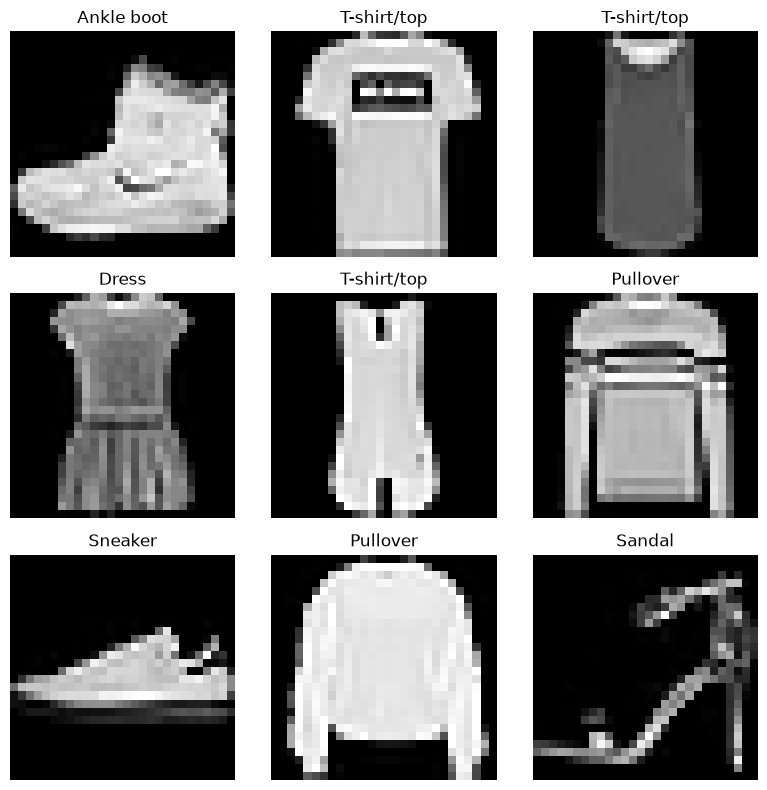

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Fashion MNIST por defecto ya viene dividido en train y test
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("Pixel mínimo:", X_train.min())
print("Pixel máximo:", X_train.max())

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

**Qué tenemos:** igual que MNIST, 60.000 imágenes para entrenar y 10.000 para probar, de 28×28 píxeles en escala de grises. La diferencia es que ahora hay **10 tipos de prenda**: remera (*T-shirt/top*), pantalón (*Trouser*), pullover, vestido (*Dress*), abrigo (*Coat*), sandalia (*Sandal*), camisa (*Shirt*), zapatilla (*Sneaker*), bolso (*Bag*) y botín (*Ankle boot*). Hay 6.000 imágenes de cada clase, así que el dataset está perfectamente balanceado.

**Qué esperar:** sandalias, zapatillas y botines tienen siluetas distintas, pero **remera, camisa, pullover y abrigo** son casi la misma silueta con diferencias sutiles (cuello, botones, largo de manga). Anticipo que serán las más difíciles: este problema es más duro que el de los dígitos.

---

## 2. Preprocesamiento

Es exactamente el mismo que en MNIST:
- **Normalizar (÷ 255):** los píxeles pasan de 0–255 a 0–1 (como pasar de "puntos sobre 255" a un porcentaje) para que el entrenamiento sea más estable y rápido.
- **Reshape (28×28 → 784):** lo hace la capa `Flatten` dentro del modelo (sección 3).

**División de los datos:** los 60.000 de train se parten con `validation_split=0.2` → 48.000 para entrenar y 12.000 para validar. Los 10.000 de test no se tocan hasta la evaluación final.

In [2]:
#Normalizamos los pixeles para trabajar en una escala más controlada
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Mínimo:", X_train.min())
print("Máximo:", X_train.max())

Mínimo: 0.0
Máximo: 1.0


___

## 3. Arquitectura

**Estructura (la ganadora de MNIST):** `Entrada (28×28) → Flatten (784) → Dense 128 (ReLU) → Dense 10 (softmax)`

### Entrada
**Flatten** convierte cada imagen de 28×28 en una lista de 784 valores, que es lo que esperan las capas Dense.

### Primera capa (oculta)
128 neuronas con **ReLU**. Se mantiene 1 sola capa oculta (Cyberdyne permite 1 o 2) y las mismas 128 neuronas para que la comparación con MNIST sea justa: si cambiáramos también la red, no sabríamos si la diferencia viene de los datos o de la arquitectura.

### Segunda capa (salida)
10 neuronas, una por tipo de prenda, con **softmax**: da 10 probabilidades que suman 1 y la prenda predicha es la de mayor probabilidad.

In [3]:
#Estructura de la RED
tf.keras.utils.set_random_seed(42)  # semilla: mismos pesos iniciales en cada ejecución
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    #Capa de activación
    tf.keras.layers.Dense(128, activation="relu"),
    #Capa calculo de probabilidad de la predicción
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Aprendizaje del modelo
- Aqui definimos el optimizador a ser usado. Para corregir los pesos.
- Como calcular el loss.
- Mostrar métricas de imagenes clasificadas correctamente.

In [4]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Entrenamiento base
Entrenamos el modelo con la configuración ganadora de MNIST (**ReLU + Adam**).
- `epochs=10`: repite el dataset de entrenamiento 10 veces (una pasada completa = 1 época).
- `batch_size=32`: por cada paso analiza 32 imágenes y recién ahí corrige los pesos.
- `validation_split=0.2`: apartamos el 20% del entrenamiento para validar mientras desarrollamos el modelo.

In [5]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 981us/step - accuracy: 0.8186 - loss: 0.5173 - val_accuracy: 0.8438 - val_loss: 0.4392
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 928us/step - accuracy: 0.8614 - loss: 0.3881 - val_accuracy: 0.8547 - val_loss: 0.4019
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 920us/step - accuracy: 0.8753 - loss: 0.3454 - val_accuracy: 0.8662 - val_loss: 0.3702
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 924us/step - accuracy: 0.8846 - loss: 0.3176 - val_accuracy: 0.8772 - val_loss: 0.3495
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 948us/step - accuracy: 0.8920 - loss: 0.2975 - val_accuracy: 0.8783 - val_loss: 0.3496
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 961us/step - accuracy: 0.8972 - loss: 0.2816 - val_accuracy: 0.8816 - val_loss: 0.3409
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 962us/step - accuracy: 0.9019 - loss: 0.2677 - val_accuracy: 0.8810 - val_loss: 0.3466
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 932us/step - accuracy: 0.9047 -

___

# 4. Experimentos

**Pregunta:** en MNIST ganó ReLU + Adam. ¿Pasa lo mismo con prendas de ropa? Repetimos las 4 combinaciones (ReLU / Sigmoid × SGD / Adam) en las **mismas condiciones** que en MNIST: misma arquitectura, 10 épocas, batch de 32, mismo 20% de validación y misma semilla. Los optimizadores usan sus valores por defecto de Keras (SGD lr=0.01, Adam lr=0.001).

**Hipótesis:** se mantiene lo de MNIST (ReLU ≥ Sigmoid y Adam > SGD), pero como Fashion MNIST es un problema más difícil, esperamos accuracies más bajas en todas las combinaciones.

In [6]:
# Función para experimentos 
def build_model(activation="relu", optimizer="sgd"):
    tf.keras.utils.set_random_seed(42)  # misma semilla => mismos pesos iniciales en los 4 experimentos
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation=activation),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

#### ReLU + SGD

In [7]:
#ReLU + SGD
model_relu_sgd = build_model("relu", "sgd")
print("ReLU + SGD")
history_relu_sgd = model_relu_sgd.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

ReLU + SGD
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 872us/step - accuracy: 0.7507 - loss: 0.7810 - val_accuracy: 0.8130 - val_loss: 0.5660
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 822us/step - accuracy: 0.8219 - loss: 0.5287 - val_accuracy: 0.8281 - val_loss: 0.5003
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 811us/step - accuracy: 0.8358 - loss: 0.4812 - val_accuracy: 0.8344 - val_loss: 0.4711
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 803us/step - accuracy: 0.8435 - loss: 0.4552 - val_accuracy: 0.8418 - val_loss: 0.4528
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - accuracy: 0.8494 - loss: 0.4369 - val_accuracy: 0.8470 - val_loss: 0.4392
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 808us/step - accuracy: 0.8534 - loss: 0.4225 - val_accuracy: 0.8504 - val_loss: 0.4285
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - accuracy: 0.8581 - loss: 0.4105 - val_accuracy: 0.8544 - val_loss: 0.4188
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 810us/step - accurac

#### Sigmoid + SGD

In [8]:
#Sigmoid + SGD
model_sigmoid_sgd = build_model("sigmoid", "sgd")
print("Sigmoid + SGD")
history_sigmoid_sgd = model_sigmoid_sgd.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Sigmoid + SGD
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - accuracy: 0.6596 - loss: 1.3500 - val_accuracy: 0.7358 - val_loss: 0.9288
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 770us/step - accuracy: 0.7463 - loss: 0.8186 - val_accuracy: 0.7605 - val_loss: 0.7312
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 759us/step - accuracy: 0.7675 - loss: 0.6939 - val_accuracy: 0.7773 - val_loss: 0.6524
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 775us/step - accuracy: 0.7834 - loss: 0.6323 - val_accuracy: 0.7918 - val_loss: 0.6064
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 895us/step - accuracy: 0.7961 - loss: 0.5925 - val_accuracy: 0.8027 - val_loss: 0.5747
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8061 - loss: 0.5636 - val_accuracy: 0.8096 - val_loss: 0.5513
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 973us/step - accuracy: 0.8127 - loss: 0.5417 - val_accuracy: 0.8158 - val_loss: 0.5332
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 955us/step - accura

#### ReLU + Adam

In [9]:
#ReLU + Adam
model_relu_adam = build_model("relu", "adam")
print("ReLU + Adam")
history_relu_adam = model_relu_adam.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

ReLU + Adam
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8186 - loss: 0.5173 - val_accuracy: 0.8438 - val_loss: 0.4392
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 954us/step - accuracy: 0.8614 - loss: 0.3881 - val_accuracy: 0.8547 - val_loss: 0.4019
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 971us/step - accuracy: 0.8753 - loss: 0.3454 - val_accuracy: 0.8662 - val_loss: 0.3702
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8846 - loss: 0.3176 - val_accuracy: 0.8772 - val_loss: 0.3495
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8920 - loss: 0.2975 - val_accuracy: 0.8783 - val_loss: 0.3496
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8972 - loss: 0.2816 - val_accuracy: 0.8816 - val_loss: 0.3409
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 969us/step - accuracy: 0.9019 - loss: 0.2677 - val_accuracy: 0.8810 - val_loss: 0.3466
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 989us/step - accuracy: 0.90

#### Sigmoid + Adam

In [10]:
#Sigmoid + Adam
model_sigmoid_adam = build_model("sigmoid", "adam")
print("Sigmoid + Adam")
history_sigmoid_adam = model_sigmoid_adam.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Sigmoid + Adam
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 973us/step - accuracy: 0.8093 - loss: 0.5632 - val_accuracy: 0.8428 - val_loss: 0.4318
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 932us/step - accuracy: 0.8549 - loss: 0.4029 - val_accuracy: 0.8586 - val_loss: 0.3885
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 930us/step - accuracy: 0.8685 - loss: 0.3647 - val_accuracy: 0.8656 - val_loss: 0.3663
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 944us/step - accuracy: 0.8774 - loss: 0.3397 - val_accuracy: 0.8718 - val_loss: 0.3523
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 987us/step - accuracy: 0.8833 - loss: 0.3206 - val_accuracy: 0.8744 - val_loss: 0.3424
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 988us/step - accuracy: 0.8892 - loss: 0.3047 - val_accuracy: 0.8760 - val_loss: 0.3354
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 990us/step - accuracy: 0.8937 - loss: 0.2911 - val_accuracy: 0.8782 - val_loss: 0.3304
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 996us/step - acc

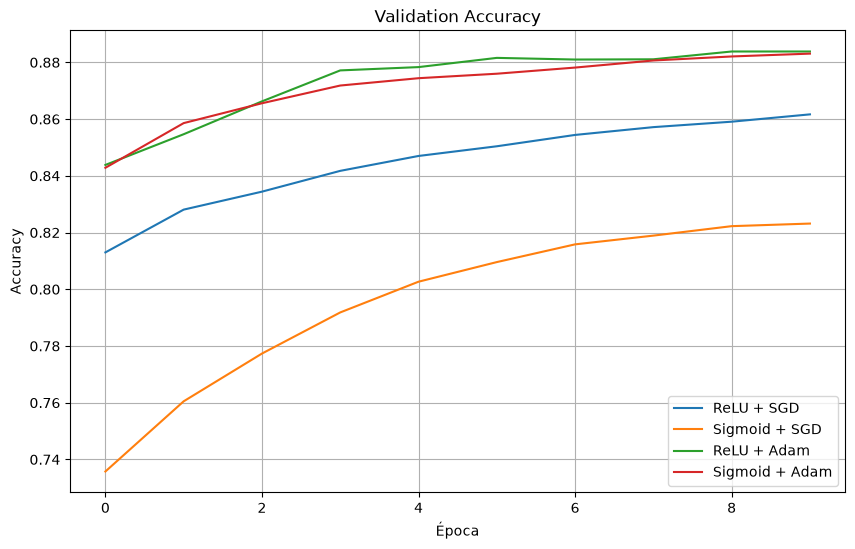

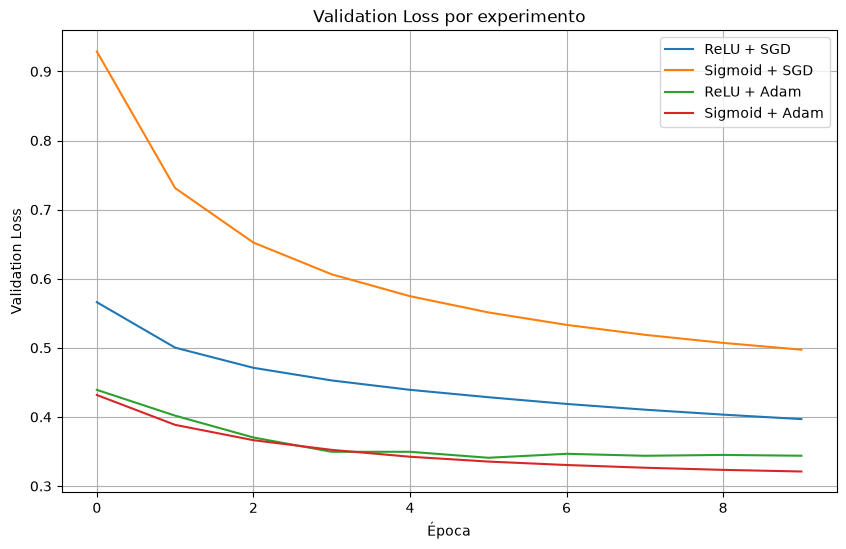

In [11]:
#Grafica Accuracy

plt.figure(figsize=(10, 6))

plt.plot(history_relu_sgd.history["val_accuracy"], label="ReLU + SGD")
plt.plot(history_sigmoid_sgd.history["val_accuracy"], label="Sigmoid + SGD")
plt.plot(history_relu_adam.history["val_accuracy"], label="ReLU + Adam")
plt.plot(history_sigmoid_adam.history["val_accuracy"], label="Sigmoid + Adam")

plt.title("Validation Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#Grafica Loss
plt.figure(figsize=(10, 6))

plt.plot(history_relu_sgd.history["val_loss"],label="ReLU + SGD")
plt.plot(history_sigmoid_sgd.history["val_loss"],label="Sigmoid + SGD")
plt.plot(history_relu_adam.history["val_loss"],label="ReLU + Adam")
plt.plot(history_sigmoid_adam.history["val_loss"],label="Sigmoid + Adam")

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.title("Validation Loss por experimento")
plt.legend()
plt.grid(True)
plt.show()



Experimento       Val acc ép.1  Val acc ép.10  Val loss ép.10  Train acc ép.10
ReLU + SGD              0.8130         0.8617          0.3969           0.8675
Sigmoid + SGD           0.7358         0.8232          0.4973           0.8271
ReLU + Adam             0.8438         0.8838          0.3438           0.9133
Sigmoid + Adam          0.8428         0.8831          0.3210           0.9054


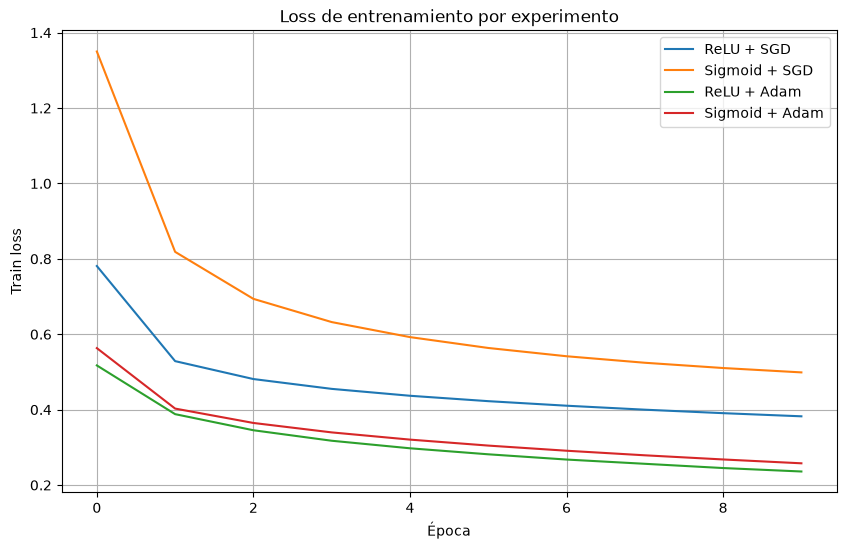

In [12]:
# Resumen de los 4 experimentos + loss de entrenamiento
experimentos = {
    "ReLU + SGD": history_relu_sgd,
    "Sigmoid + SGD": history_sigmoid_sgd,
    "ReLU + Adam": history_relu_adam,
    "Sigmoid + Adam": history_sigmoid_adam,
}

print(f"{'Experimento':<16}{'Val acc ép.1':>14}{'Val acc ép.10':>15}{'Val loss ép.10':>16}{'Train acc ép.10':>17}")
for nombre, h in experimentos.items():
    hh = h.history
    print(f"{nombre:<16}{hh['val_accuracy'][0]:>14.4f}{hh['val_accuracy'][-1]:>15.4f}{hh['val_loss'][-1]:>16.4f}{hh['accuracy'][-1]:>17.4f}")

plt.figure(figsize=(10, 6))
for nombre, h in experimentos.items():
    plt.plot(h.history["loss"], label=nombre)
plt.title("Loss de entrenamiento por experimento")
plt.xlabel("Época")
plt.ylabel("Train loss")
plt.legend()
plt.grid(True)
plt.show()

### Resultados de los experimentos (validación, época 10)

| | ReLU | Sigmoid |
|---|---|---|
| **SGD** | 86.2% | 82.3% |
| **Adam** | 88.5% | 88.3% |

- **Adam vs SGD:** se repite lo de MNIST, Adam gana. En 3 épocas Adam ya supera lo que ReLU + SGD logra en 10 (86.9% vs 86.2%).
- **ReLU vs Sigmoid:** con SGD, ReLU gana por casi 4 puntos y Sigmoid + SGD es la peor combinación (82.3%, todavía lejos de su techo). Con Adam empatan: la diferencia (0.2 puntos) es ruido y, de hecho, Sigmoid + Adam tiene menor val loss (0.321 vs 0.346).
- **Conclusión:** lo que ganó en MNIST sigue ganando acá (aunque por poco entre ReLU y Sigmoid con Adam), así que seguimos con **ReLU + Adam**.
- **Todo rinde menos que en MNIST** (~88% vs ~97%): es un problema más difícil.
- **Overfitting:** con ReLU + Adam el train llega a 91.4% contra 88.5% de validation, una brecha de ~3 puntos.

___

# 5. Evaluación


### Configuración elegida: ReLU + Adam

Es la configuración ganadora de MNIST y también la mejor en Fashion MNIST por accuracy de validación (88.5%), aunque por muy poco frente a Sigmoid + Adam (88.3%): en la práctica es un empate. Nos quedamos con **ReLU + Adam** porque la consigna es reutilizar la arquitectura ganadora del experimento anterior y porque, con SGD, ReLU le gana claramente a Sigmoid. La reentrenamos como **modelo final** (con la misma semilla debe dar el mismo resultado que en el experimento) y la evaluamos en test.

In [13]:
model_final = build_model("relu", "adam")
history_final = model_final.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8186 - loss: 0.5173 - val_accuracy: 0.8438 - val_loss: 0.4392
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 948us/step - accuracy: 0.8614 - loss: 0.3881 - val_accuracy: 0.8547 - val_loss: 0.4019
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 945us/step - accuracy: 0.8753 - loss: 0.3454 - val_accuracy: 0.8662 - val_loss: 0.3702
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 937us/step - accuracy: 0.8846 - loss: 0.3176 - val_accuracy: 0.8772 - val_loss: 0.3495
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 939us/step - accuracy: 0.8920 - loss: 0.2975 - val_accuracy: 0.8783 - val_loss: 0.3496
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 935us/step - accuracy: 0.8972 - loss: 0.2816 - val_accuracy: 0.8816 - val_loss: 0.3409
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 944us/step - accuracy: 0.9019 - loss: 0.2677 - val_accuracy: 0.8810 - val_loss: 0.3466
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 949us/step - accuracy: 0.9047 - l

### Examen final: evaluación en test
Hasta acá solo usamos train y validation para decidir. Ahora, **una única vez**, evaluamos con las 10.000 imágenes de test que el modelo nunca vio.

In [14]:
test_loss, test_accuracy = model_final.evaluate(
    X_test,
    y_test
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - accuracy: 0.8723 - loss: 0.3733
Test loss: 0.3733179569244385
Test accuracy: 0.8723000288009644


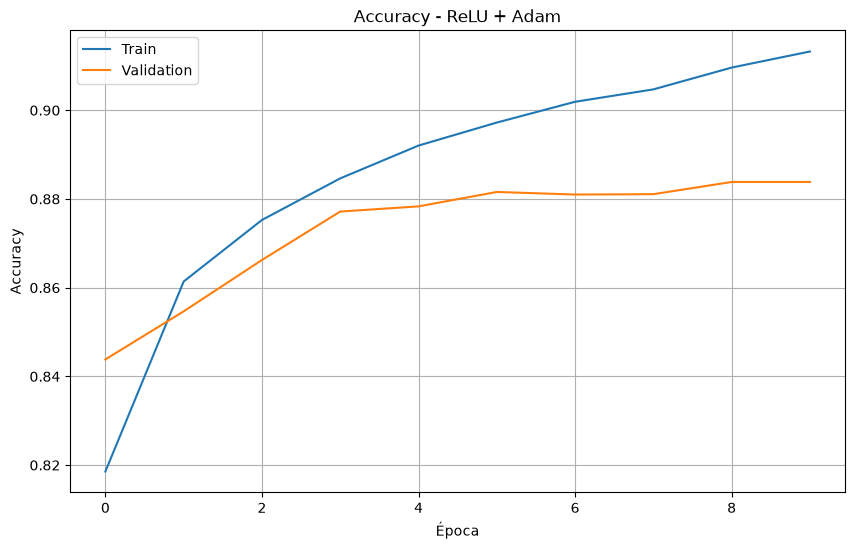

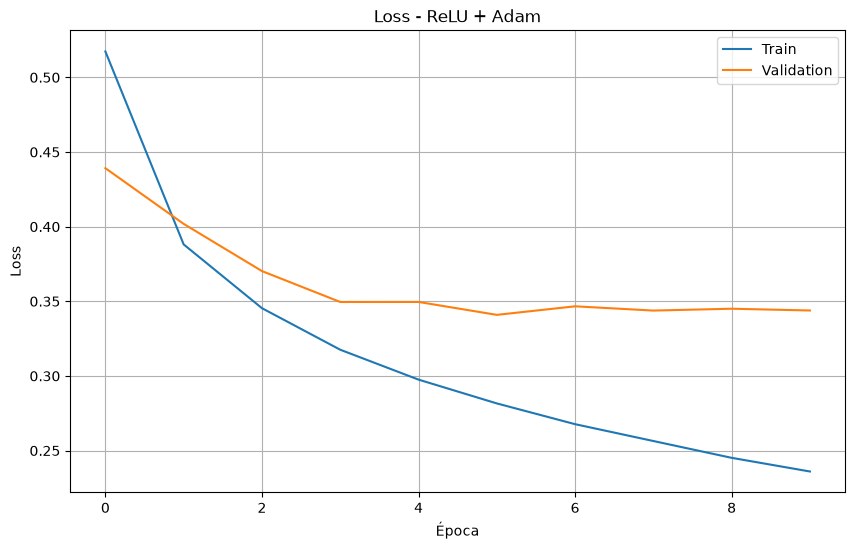

In [15]:
#Grafica Accuracy

plt.figure(figsize=(10, 6))

plt.plot(history_final.history["accuracy"], label="Train")
plt.plot(history_final.history["val_accuracy"], label="Validation")

plt.title("Accuracy - ReLU + Adam")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#Grafica Loss
plt.figure(figsize=(10, 6))

plt.plot(history_final.history["loss"], label="Train")
plt.plot(history_final.history["val_loss"], label="Validation")

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss - ReLU + Adam")
plt.legend()
plt.grid(True)
plt.show()

### Cómo leer las curvas
- **Accuracy:** el train sube hasta ~91.4%, mientras validation queda entre 87.7% y 88.5% desde la época 4.
- **Loss:** el train loss baja siempre (0.23 al final), pero el val loss se estanca en ~0.34–0.35 desde la época 4: mismo patrón que en MNIST.
- **Diagnóstico:** **overfitting leve.** La red sigue aprendiendo el set de entrenamiento pero ya no mejora con datos nuevos. Para prendas de ropa, además, esa brecha de ~3 puntos es más difícil de cerrar porque las clases se parecen entre sí.

### Matriz de confusión
Cada **fila** es la prenda real y cada **columna** la prenda que predijo el modelo. La **diagonal** son los aciertos y lo que queda fuera son errores. Por ejemplo, la celda de la fila *Shirt* y columna *T-shirt/top* responde: *¿cuántas camisas reales creyó el modelo que eran remeras?*

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 459us/step


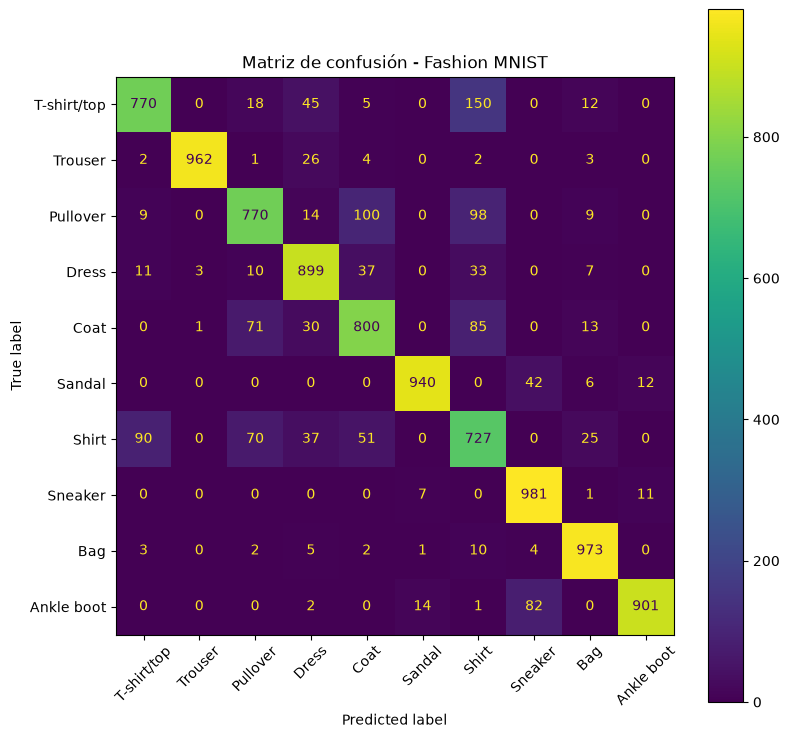

Clasificadas correctamente: 8723 de 10000
Clasificadas incorrectamente: 1277

Confusiones más frecuentes (real → predicho):
  T-shirt/top → Shirt: 150 veces
  Pullover → Coat: 100 veces
  Pullover → Shirt: 98 veces
  Shirt → T-shirt/top: 90 veces
  Coat → Shirt: 85 veces


In [16]:
y_pred_prob = model_final.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)



cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Matriz de confusión - Fashion MNIST")
plt.show()

aciertos_total = (y_pred == y_test).sum()
print(f"Clasificadas correctamente: {aciertos_total} de {len(y_test)}")
print(f"Clasificadas incorrectamente: {len(y_test) - aciertos_total}")

# Las confusiones más frecuentes (fuera de la diagonal)
cm_errores = cm.copy()
np.fill_diagonal(cm_errores, 0)
print("\nConfusiones más frecuentes (real → predicho):")
for idx in np.argsort(cm_errores, axis=None)[::-1][:5]:
    real, pred = divmod(idx, 10)
    print(f"  {class_names[real]} → {class_names[pred]}: {cm_errores[real, pred]} veces")

**Qué muestra:** la diagonal es fuerte en las prendas de forma muy distinta: zapatilla (981 de 1.000), bolso (981), pantalón (969), sandalia (948) y botín (917). Los errores se concentran en las prendas de torso: **T-shirt → Shirt (166)**, **Pullover → Coat (99)**, **Shirt → T-shirt (90)**, **Coat → Pullover (87)** y **Shirt → Pullover (83)**. La clase más difícil es **Shirt**: solo acierta 712 de 1.000 (71%). En total son 1.244 errores sobre 10.000 imágenes (12.4%).

### Aciertos y errores
Abajo, 5 aciertos y 5 errores (verde = acierto, rojo = error) con qué tan seguro estaba el modelo en cada caso. Después miramos en detalle **el error más "confiado"**: el que el modelo cometió estando más seguro.

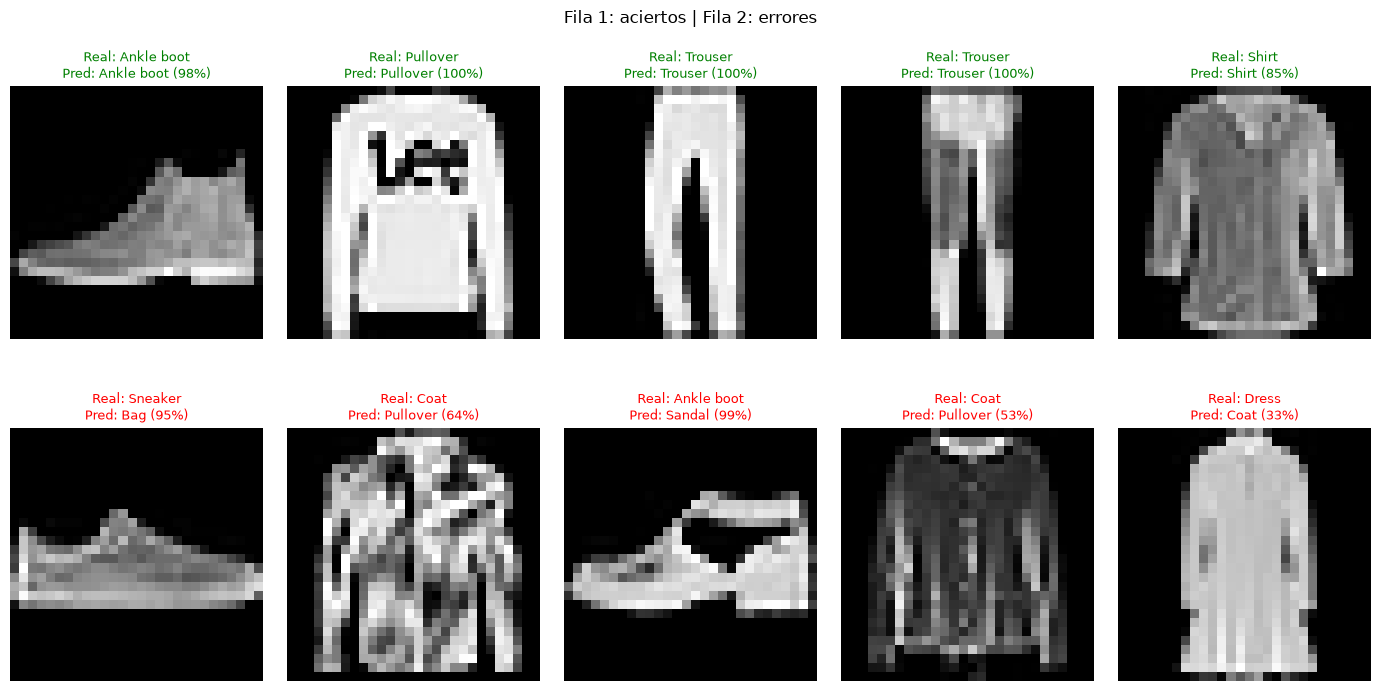

In [17]:
# 5 aciertos y 5 errores (los primeros que aparecen en test)
aciertos = np.where(y_test == y_pred)[0][:5]
errores = np.where(y_test != y_pred)[0][:5]

plt.figure(figsize=(14, 7))
for k, idx in enumerate(np.concatenate([aciertos, errores])):
    plt.subplot(2, 5, k + 1)
    plt.imshow(X_test[idx], cmap="gray")
    color = "green" if y_test[idx] == y_pred[idx] else "red"
    seguridad = y_pred_prob[idx].max() * 100
    plt.title(f"Real: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]} ({seguridad:.0f}%)", color=color, fontsize=9)
    plt.axis("off")
plt.suptitle("Fila 1: aciertos | Fila 2: errores")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.35)
plt.show()

Cantidad de errores: 1277
Índice de la imagen: 5235
Etiqueta real: Sandal
Predicción: Bag


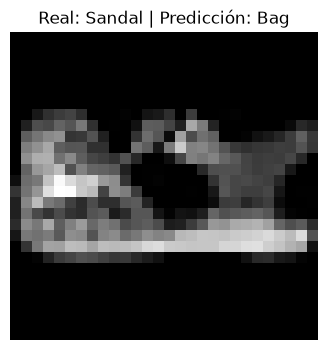

Probabilidades(que tan seguro estaba el modelo):
T-shirt/top: 0.0000
Trouser: 0.0000
Pullover: 0.0000
Dress: 0.0000
Coat: 0.0000
Sandal: 0.0000
Shirt: 0.0000
Sneaker: 0.0000
Bag: 1.0000
Ankle boot: 0.0000


In [18]:
incorrectos = np.where(y_test != y_pred)[0]

print("Cantidad de errores:", len(incorrectos))

# El error más "confiado": el modelo estaba muy seguro y aun así se equivocó
i = incorrectos[np.argmax(y_pred_prob[incorrectos].max(axis=1))]

print("Índice de la imagen:", i)
print("Etiqueta real:", class_names[y_test[i]])
print("Predicción:", class_names[y_pred[i]])

plt.figure(figsize=(4, 4))
plt.imshow(X_test[i], cmap="gray")
plt.title(
    f"Real: {class_names[y_test[i]]} | Predicción: {class_names[y_pred[i]]}"
)

plt.axis("off")
plt.show()


print("Probabilidades(que tan seguro estaba el modelo):")
for clase, probabilidad in enumerate(y_pred_prob[i]):
    print(f"{class_names[clase]}: {probabilidad:.4f}")

### Análisis del error
- **Errores típicos (fila roja):** son casi todos del tipo esperado, prendas de torso confundidas entre sí (Coat → Pullover, Shirt → T-shirt/top, Dress → Shirt). Muchas veces son difíciles incluso para una persona: en 28×28 y escala de grises se pierden el cuello, los botones y la textura, que son justo lo que diferencia una camisa de una remera.
- **El caso más extremo:** una **sandalia clasificada como bolso con ~100% de seguridad**. Mi hipótesis: es una imagen oscura y de bajo contraste, con tiras anchas que forman una silueta horizontal y cerrada, parecida a la de un bolso. Con solo 784 números sueltos la red no puede "ver" que hay tiras y una suela.
- **Causa de fondo:** `Flatten + Dense` trata cada píxel por separado y no sabe cuáles son vecinos, por eso le cuesta captar bordes y texturas. Una **red convolucional (CNN)** sí lo hace.

# 6. Conclusiones

> Los números de esta sección corresponden a una ejecución con semilla fija (`42`). Si se corre en otra máquina pueden variar unas décimas.

## Comparación con MNIST

| | MNIST | Fashion MNIST |
|---|---|---|
| **Accuracy en test** | 97.1% | 87.6% |
| **Errores en test (de 10.000)** | 291 | 1.244 |
| **Accuracy de train (época 10)** | 99.6% | 91.4% |
| **Confusión más frecuente** | 9 → 7 (17 veces) | T-shirt → Shirt (166 veces) |

La **misma arquitectura** rindió ~9.5 puntos peor en prendas. No es que la red sea "peor": el problema es más difícil. Los dígitos tienen trazos bastante distintos entre sí, mientras que remera, camisa, pullover y abrigo comparten silueta y se diferencian por detalles finos que una red que ve píxeles sueltos no capta.

## Qué ganó
- **Arquitectura:** `Flatten → Dense(128, ReLU) → Dense(10, softmax)`, la misma que en MNIST.
- **Optimizador:** **Adam**, otra vez claramente mejor que SGD.
- **Activación:** ReLU + Adam quedó primera por muy poco frente a Sigmoid + Adam (empate técnico).
- **Resultado final en test: 87.6%** (8.756 aciertos y 1.244 errores).

## Qué salió mal
1. **Sigmoid + SGD fue la peor combinación** (82.3%) y sigue lejos de su techo después de 10 épocas.
2. **La clase Shirt no se pudo resolver:** solo 71% de aciertos, y se confunde con remera, pullover y abrigo. Con esta arquitectura no hay mucho más que ajustar; el problema es la falta de información espacial.
3. **La red es sobreconfiada:** clasificó una sandalia como bolso con ~100% de seguridad. Un modelo así no debería usarse a ciegas.
5. **Las mismas limitaciones que en MNIST:** una sola corrida por configuración y las tasas de aprendizaje por defecto de cada optimizador.

## Qué cambiaría
- Una **CNN**, que es el paso natural para imágenes de ropa.
- Probar una **segunda capa oculta**  o más neuronas, y agregar **Dropout** y **Early Stopping**.
- Aumento de datos (*data augmentation*) para que la red vea más variaciones de cada prenda.

## Qué aprendí
- Una arquitectura que funciona muy bien en un dataset no garantiza lo mismo en otro: **el problema manda**.
- Mirar la matriz de confusión ayuda a entender la dificultad real (la accuracy promedio esconde que Shirt está en 71% y Sneaker en 98%).
- Los resultados con diferencias de décimas hay que tomarlos con pinzas: sin repetir corridas no se puede afirmar que uno sea mejor que otro.